In [28]:
from pymoo.problems import get_problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

n_obj = 3
k = 10
n_var = n_obj + k - 1

problem = get_problem(
    "dtlz3",
    n_var=n_var,
    n_obj=n_obj
)

print(problem.n_var)   # 12
print(problem.n_obj)   # 3
print(problem.xl)      # lower bounds
print(problem.xu)      # upper bounds

12
3
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [29]:
algorithm = NSGA2(
    pop_size=1_000
)

result = minimize(
    problem,
    algorithm,
    termination=("n_gen", 200),
    seed=1,
    verbose=True
)

X = result.X   # Pareto decision vectors
F = result.F   # Pareto objective vectors

print(X.shape)
print(F.shape)

n_gen  |  n_eval  | n_nds  |      igd      |       gd     
     1 |     1000 |     38 |  3.725745E+02 |  7.912580E+02
     2 |     2000 |     47 |  3.725745E+02 |  7.953026E+02
     3 |     3000 |     67 |  2.355306E+02 |  7.788569E+02
     4 |     4000 |     43 |  2.060057E+02 |  7.052650E+02
     5 |     5000 |     46 |  1.903188E+02 |  6.027814E+02
     6 |     6000 |     64 |  1.903188E+02 |  5.933408E+02
     7 |     7000 |     70 |  1.903188E+02 |  6.060688E+02
     8 |     8000 |     80 |  1.799829E+02 |  5.365411E+02
     9 |     9000 |     77 |  1.799829E+02 |  5.188623E+02
    10 |    10000 |    101 |  1.799829E+02 |  4.974854E+02
    11 |    11000 |    112 |  1.337368E+02 |  5.363248E+02
    12 |    12000 |    131 |  1.337368E+02 |  5.752131E+02
    13 |    13000 |    114 |  1.337368E+02 |  5.061602E+02
    14 |    14000 |    121 |  1.337368E+02 |  4.922281E+02
    15 |    15000 |    117 |  1.310145E+02 |  4.890343E+02
    16 |    16000 |    115 |  1.310145E+02 |  4.958285E+

In [30]:
from eda_emna import ContEDA
import os
import pickle

In [31]:
cont_eda = ContEDA(
    problem, 
    pop_size=1_000, 
    generations=150, 
    max_no_improve_gen=3, 
    max_row_diff=0.1, 
    seed=1123
)
results = cont_eda.run()
results_path = f"eda_conti_results/test_dtlz3_3obj.pkl"

if os.path.exists(results_path):
    raise ValueError(f"File {results_path} already exists")
with open(results_path, "wb") as f:
    pickle.dump(results, f)   


Mode 1 generation 1 (no improve count: 0)
Mode 1 generation 2 (no improve count: 0)
Mode 1 generation 3 (no improve count: 0)
Mode 1 generation 4 (no improve count: 0)
Mode 1 generation 5 (no improve count: 0)
Mode 1 generation 6 (no improve count: 1)
Mode 1 generation 7 (no improve count: 2)
Mode 2 generation 1 (no improve count: 0)
Mode 2 generation 2 (no improve count: 0)
Mode 2 generation 3 (no improve count: 0)
Mode 2 generation 4 (no improve count: 0)
Mode 2 generation 5 (no improve count: 0)
Mode 2 generation 6 (no improve count: 0)
Mode 2 generation 7 (no improve count: 0)
Mode 2 generation 8 (no improve count: 0)
Mode 2 generation 9 (no improve count: 0)
Mode 2 generation 10 (no improve count: 0)
Mode 2 generation 11 (no improve count: 0)
Mode 2 generation 12 (no improve count: 0)
Mode 2 generation 13 (no improve count: 1)
Mode 2 generation 14 (no improve count: 2)
EDA finished in 10.27s (mode 1: 7 gens, mode 2: 14 gens)


In [26]:
with open(f"eda_conti_results/test_dtlz2_5obj.pkl", "rb") as f:
    results = pickle.load(f)

In [ ]:
results['js_div_list'][140:150]

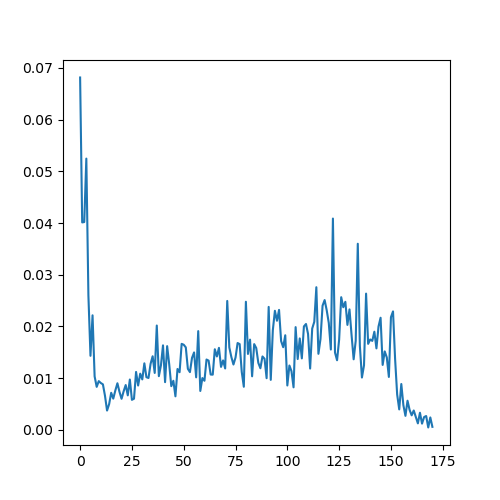

In [27]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()
ax.plot(results['js_div_list'])

In [32]:
F_eda = results['converged_pf_table'][-1]

In [24]:
import numpy as np

ref_point = np.full(n_obj, 1.2)

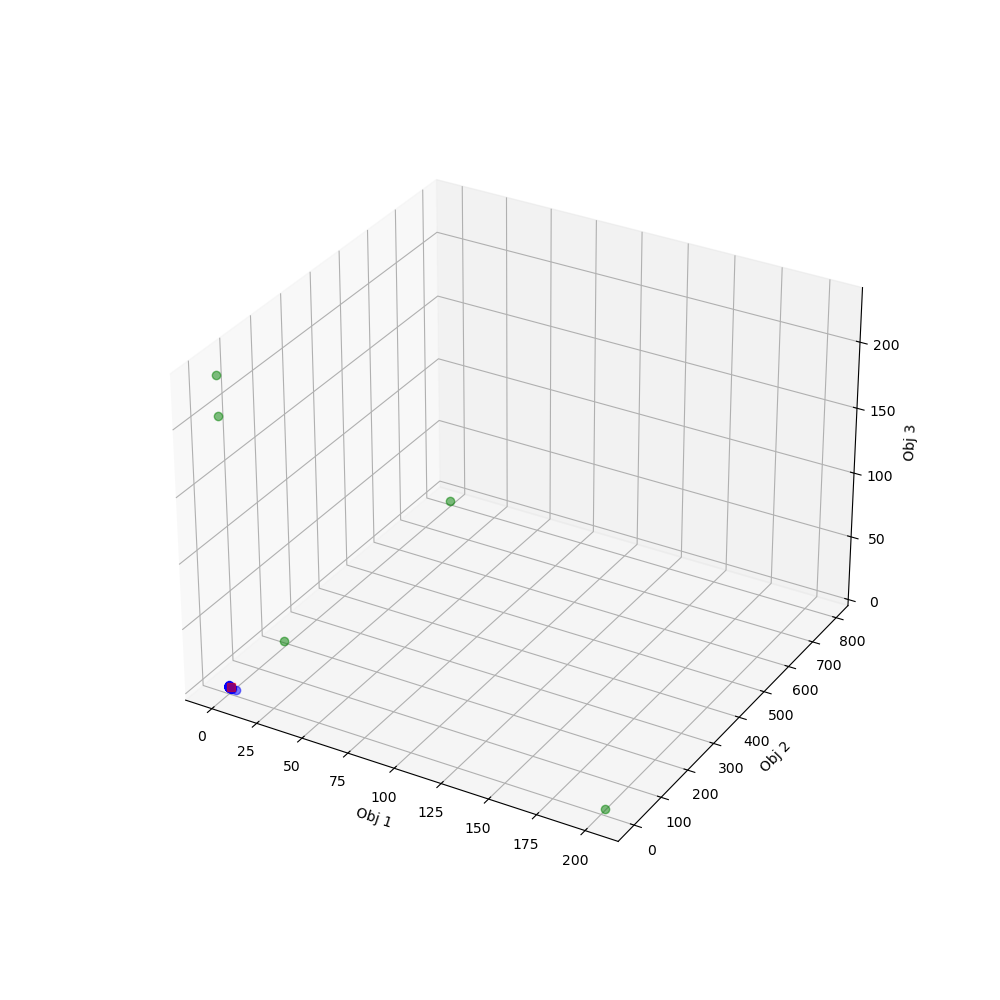

In [34]:
import matplotlib.pyplot as plt
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.plot(F[:,0], F[:,1], F[:,2], 'bo', alpha=0.5, markersize=6)
ax.plot(F_eda[:,0], F_eda[:,1], F_eda[:,2], 'go', alpha=0.5, markersize=6)
ax.plot(ref_point[0], ref_point[1], ref_point[2], 'rs', alpha=0.5, markersize=6)
ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.show()

In [25]:
from pymoo.indicators.hv import HV

hv = HV(ref_point=ref_point)
hv_F = hv(F)
hv_F_eda = hv(F_eda)
print(hv_F)
print(hv_F_eda)

1.173673181953653
1.1824440235414837


1. IGD as a metric

2. compute closed formed mom

3. change mode 1 convergence criterion

4. test different objectives

Fitting error analysis

In [ ]:
from scipy.stats._warnings_errors import FitError 
import numpy as np
 
try:
    results = cont_eda.run()
except FitError as e:
    tb = e.__traceback__
    while tb is not None:
        if tb.tb_frame.f_code.co_name == "fit_beta_GC":
            failed = dict(tb.tb_frame.f_locals)
        tb = tb.tb_next
j = failed["j"]
col = failed["X"][:, j]
print("failing column:", j)
print("min / max / std:", col.min(), col.max(), col.std())
print("frac near 0 / 1:", (col <= 1e-3).mean(), (col >= 1 - 1e-3).mean())
print("unique values:", len(np.unique(col)))

In [ ]:
import numpy as np

X = cont_eda.selected_population
F = cont_eda.problem.evaluate(X)
print("column std:", X.std(axis=0).round(4))
print("mean of x[2:]:", X[:, 2:].mean(axis=0).round(4))
g = ((X[:, 2:] - 0.5) ** 2).sum(axis=1)
print("g: min %.2e  median %.2e  max %.2e" % (g.min(), np.median(g), g.max()))
print("|F| - 1 (should be ~0):", np.median(np.linalg.norm(F, axis=1) - 1))

In [ ]:
X = cont_eda.selected_population
for j in (0, 1):
    print(j, (X[:, j] < 1e-3).mean(), (X[:, j] > 1 - 1e-3).mean())